1. What is Unsupervised Learning?
Unsupervised learning is a type of machine learning where there are no labeled outputs.
The model finds patterns or groups in data automatically.
Example: Customer segmentation.

2. How does K-Means Clustering work?
- Choose K (number of clusters)
- Initialize centroids randomly
- Assign points to nearest centroid
- Recalculate centroids
- Repeat until convergence

3. What is a Dendrogram?
A dendrogram is a tree-like diagram used in hierarchical clustering to show how clusters are merged or split.

4. Difference between K-Means and Hierarchical Clustering:
- K-Means: Fast, needs K, produces flat clusters
- Hierarchical: Slow, no need for K, produces tree structure

5. Advantages of DBSCAN over K-Means:
- Detects arbitrary shaped clusters
- Handles noise/outliers
- No need to specify number of clusters

6. When to use Silhouette Score?
Used to evaluate clustering quality and choose optimal clusters.
Range: -1 to 1 (higher is better)

7. Limitations of Hierarchical Clustering:
- High computational cost
- Not scalable
- Cannot undo merges
- Sensitive to noise

8. Why Feature Scaling is important?
Because clustering uses distance (Euclidean), features with large values dominate results.

9. How does DBSCAN identify noise points?
Points that are not within eps distance of enough neighbors (minPts) are labeled as noise.

10. Define Inertia in K-Means:
Inertia is the sum of squared distances between data points and their cluster centroids.

11. What is the Elbow Method?
A method to find optimal K by plotting inertia vs K and finding the "elbow" point.

12. What is "density" in DBSCAN?
Density means number of points within a radius (eps). High density forms clusters.

13. Can Hierarchical Clustering be used on categorical data?
Yes, using appropriate distance measures like Hamming distance.

14. What does a negative Silhouette Score indicate?
It indicates wrong clustering (points assigned to incorrect clusters).

15. What is Linkage Criteria?
It defines how distance between clusters is calculated (single, complete, average linkage).

16. Why K-Means performs poorly on varying cluster sizes?
Because it assumes clusters are spherical and equal in size and density.

17. Core parameters in DBSCAN:
- eps: radius of neighborhood
- minPts: minimum points to form a cluster

18. How K-Means++ improves K-Means?
It initializes centroids more carefully to improve convergence and accuracy.

19. What is Agglomerative Clustering?
A bottom-up approach where each point starts as a cluster and merges step by step.

20. Why Silhouette Score is better than inertia?
Inertia only measures compactness, while Silhouette considers both compactness and separation.

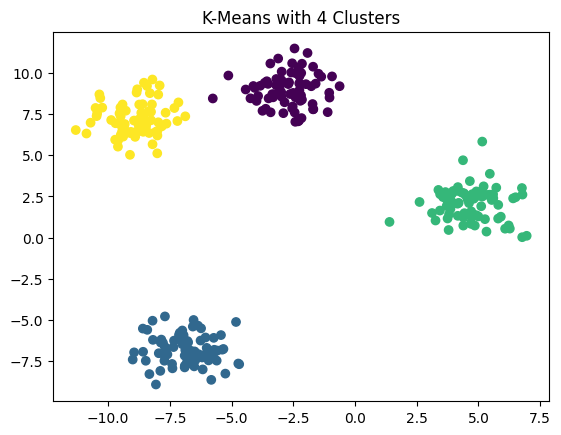

In [1]:
# Generate synthetic data with 4 centers using make_blobs 
# and apply K-Means clustering. Visualize using a scatter plot

import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

X, _ = make_blobs(n_samples=300, centers=4, random_state=42)

kmeans = KMeans(n_clusters=4, random_state=42)
labels = kmeans.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=labels)
plt.title("K-Means with 4 Clusters")
plt.show()

In [2]:
# Load the Iris dataset and use Agglomerative Clustering 
# to group the data into 3 clusters. Display the first 10 predicted labels

from sklearn.datasets import load_iris
from sklearn.cluster import AgglomerativeClustering

iris = load_iris()
X = iris.data

agg = AgglomerativeClustering(n_clusters=3)
labels = agg.fit_predict(X)

print(labels[:10])

[1 1 1 1 1 1 1 1 1 1]


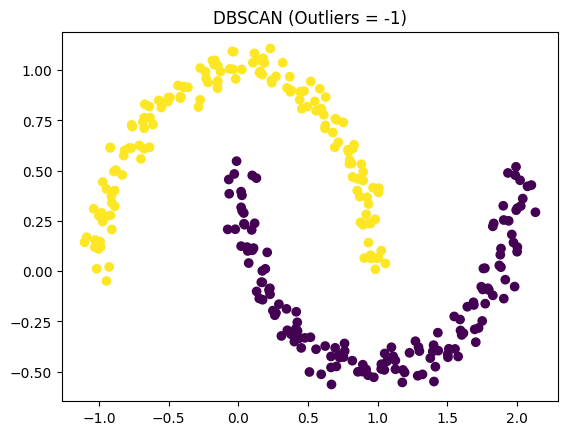

In [3]:
# Generate synthetic data using make_moons and apply DBSCAN. 
# Highlight outliers in the plot

import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN

X, _ = make_moons(n_samples=300, noise=0.05, random_state=42)

db = DBSCAN(eps=0.3, min_samples=5)
labels = db.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=labels)
plt.title("DBSCAN (Outliers = -1)")
plt.show()

In [4]:
# Load the Wine dataset and apply K-Means clustering after standardizing the features. 
# Print the size of each cluster

import numpy as np
from sklearn.datasets import load_wine
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

wine = load_wine()
X = StandardScaler().fit_transform(wine.data)

kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X)

unique, counts = np.unique(labels, return_counts=True)
print(dict(zip(unique, counts)))

{np.int32(0): np.int64(65), np.int32(1): np.int64(51), np.int32(2): np.int64(62)}


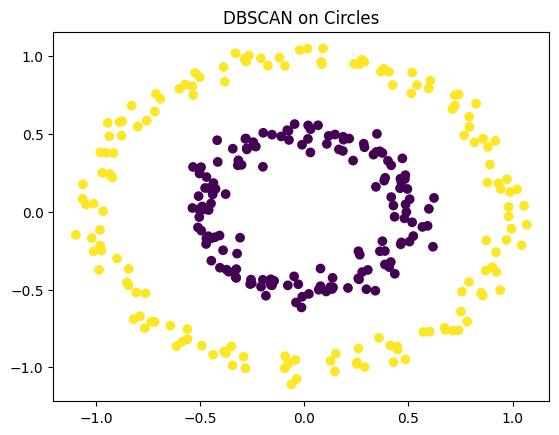

In [5]:
# Use make_circles to generate synthetic data and cluster it using DBSCAN. Plot the result

import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.cluster import DBSCAN

X, _ = make_circles(n_samples=300, noise=0.05, factor=0.5, random_state=42)

db = DBSCAN(eps=0.2, min_samples=5)
labels = db.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=labels)
plt.title("DBSCAN on Circles")
plt.show()

In [6]:
# Load the Breast Cancer dataset, apply MinMaxScaler, and use K-Means with 2 clusters. 
# Output the cluster centroids

from sklearn.datasets import load_breast_cancer
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

cancer = load_breast_cancer()
X = MinMaxScaler().fit_transform(cancer.data)

kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X)

print(kmeans.cluster_centers_)

[[0.50483563 0.39560329 0.50578661 0.36376576 0.46988732 0.42226302
  0.41838662 0.46928035 0.45899738 0.29945886 0.19093085 0.19112073
  0.17903433 0.13086432 0.18017962 0.25890126 0.12542475 0.30942779
  0.190072   0.13266975 0.48047448 0.45107371 0.4655302  0.31460597
  0.49868817 0.36391461 0.39027292 0.65827197 0.33752296 0.26041387]
 [0.25535358 0.28833455 0.24696416 0.14388369 0.35743076 0.18019471
  0.10344776 0.1306603  0.34011829 0.25591606 0.06427485 0.18843043
  0.05975663 0.02870108 0.18158628 0.13242941 0.05821528 0.18069336
  0.17221057 0.08403996 0.2052406  0.32069002 0.19242138 0.09943446
  0.3571115  0.14873935 0.13142287 0.26231363 0.22639412 0.15437354]]


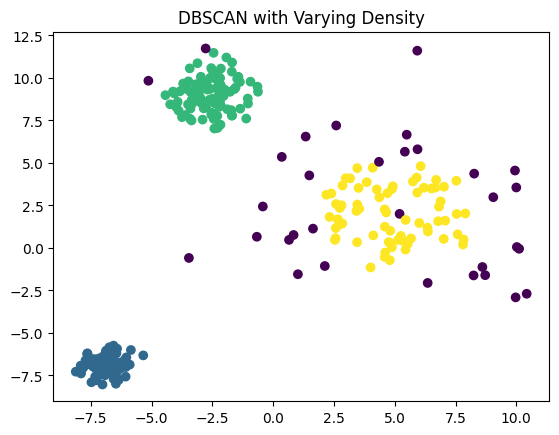

In [7]:
# Generate synthetic data using make_blobs with varying cluster standard deviations 
# and cluster with DBSCAN

import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import DBSCAN

X, _ = make_blobs(n_samples=300, centers=3, cluster_std=[1.0, 2.5, 0.5], random_state=42)

db = DBSCAN(eps=0.9, min_samples=5)
labels = db.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=labels)
plt.title("DBSCAN with Varying Density")
plt.show()

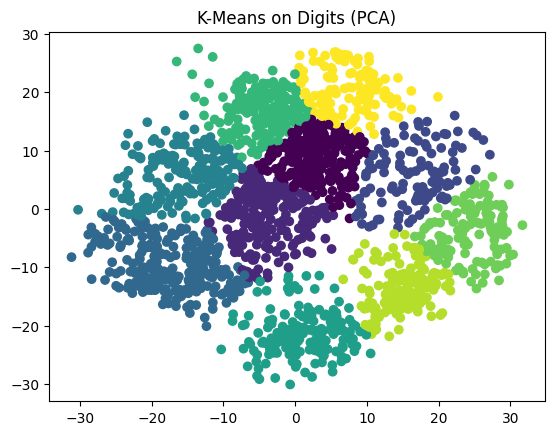

In [8]:
# Load the Digits dataset, reduce it to 2D using PCA, 
# and visualize clusters from K-Means

import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

digits = load_digits()
X = digits.data

X_pca = PCA(n_components=2).fit_transform(X)

kmeans = KMeans(n_clusters=10, random_state=42)
labels = kmeans.fit_predict(X_pca)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels)
plt.title("K-Means on Digits (PCA)")
plt.show()

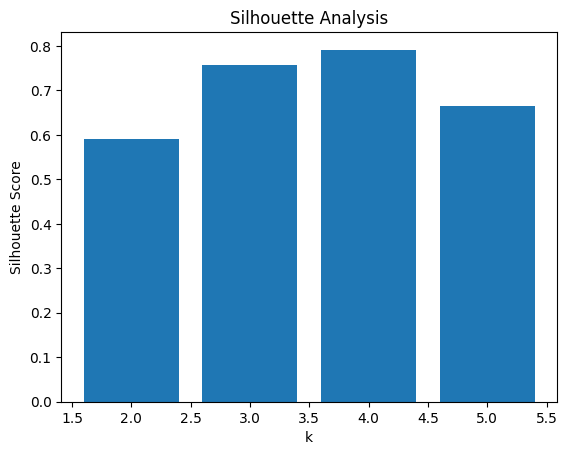

In [9]:
# Create synthetic data using make_blobs and evaluate silhouette scores 
# for k = 2 to 5. Display as a bar chart

import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X, _ = make_blobs(n_samples=300, centers=4, random_state=42)

scores = []
k_values = range(2, 6)

for k in k_values:
    labels = KMeans(n_clusters=k, random_state=42).fit_predict(X)
    score = silhouette_score(X, labels)
    scores.append(score)

plt.bar(k_values, scores)
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")
plt.show()

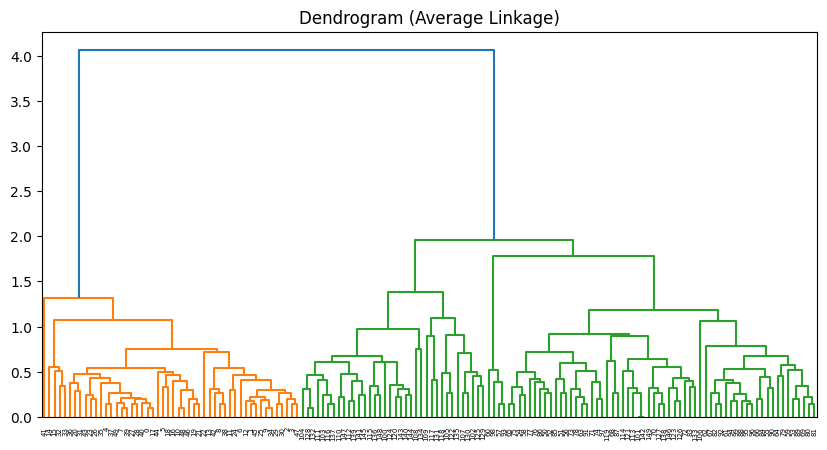

In [10]:
# Load the Iris dataset and use hierarchical clustering to group data. 
# Plot a dendrogram with average linkage

import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from scipy.cluster.hierarchy import dendrogram, linkage

iris = load_iris()
X = iris.data

Z = linkage(X, method='average')

plt.figure(figsize=(10, 5))
dendrogram(Z)
plt.title("Dendrogram (Average Linkage)")
plt.show()

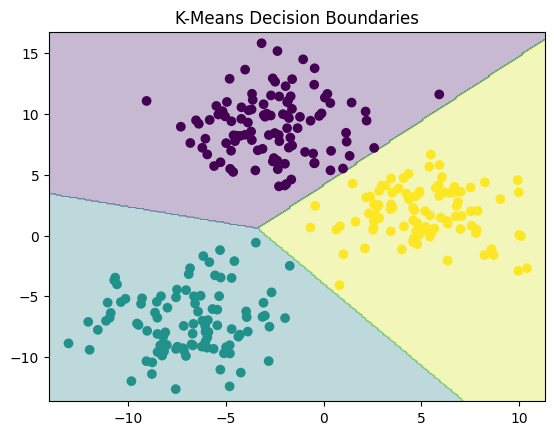

In [12]:
# Generate synthetic data with overlapping clusters using make_blobs, 
# apply K-Means and visualize with decision boundaries

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

X, _ = make_blobs(n_samples=300, centers=3, cluster_std=2.5, random_state=42)

kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X)

# Decision boundary
x_min, x_max = X[:, 0].min()-1, X[:, 0].max()+1
y_min, y_max = X[:, 1].min()-1, X[:, 1].max()+1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

Z = kmeans.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X[:, 0], X[:, 1], c=kmeans.labels_)
plt.title("K-Means Decision Boundaries")
plt.show()

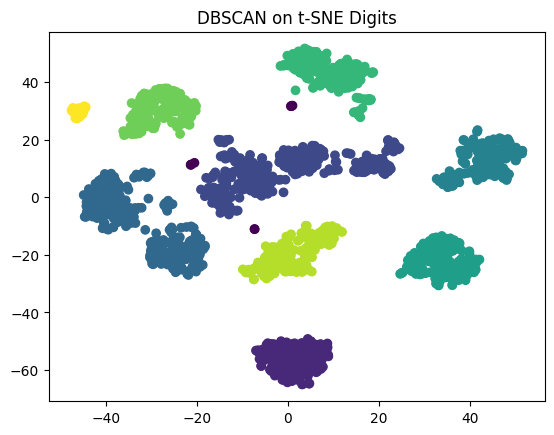

In [13]:
# Load the Digits dataset and apply DBSCAN after reducing dimensions with t-SNE. Visualize results

import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.manifold import TSNE
from sklearn.cluster import DBSCAN

digits = load_digits()
X = digits.data

X_tsne = TSNE(n_components=2, random_state=42).fit_transform(X)

db = DBSCAN(eps=5, min_samples=5)
labels = db.fit_predict(X_tsne)

plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels)
plt.title("DBSCAN on t-SNE Digits")
plt.show()

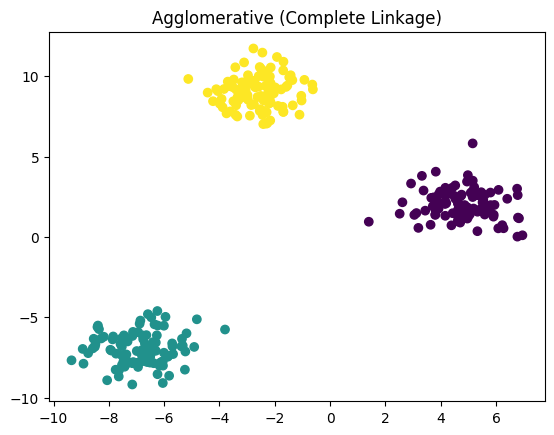

In [14]:
# Generate synthetic data using make_blobs and apply Agglomerative Clustering 
# with complete linkage. Plot the result

import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering

X, _ = make_blobs(n_samples=300, centers=3, random_state=42)

agg = AgglomerativeClustering(n_clusters=3, linkage='complete')
labels = agg.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=labels)
plt.title("Agglomerative (Complete Linkage)")
plt.show()

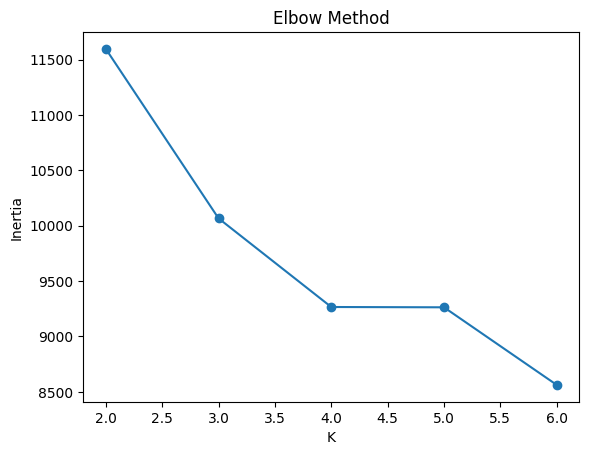

In [15]:
# Load the Breast Cancer dataset and compare inertia values for K = 2 to 6 
# using K-Means. Show results in a line plot

import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

X = StandardScaler().fit_transform(load_breast_cancer().data)

inertia = []
k_values = range(2, 7)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.plot(k_values, inertia, marker='o')
plt.xlabel("K")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

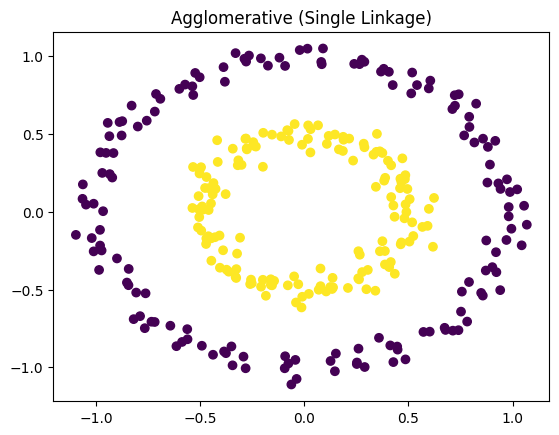

In [16]:
# Generate synthetic concentric circles using make_circles and 
# cluster using Agglomerative Clustering with single linkage

import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.cluster import AgglomerativeClustering

X, _ = make_circles(n_samples=300, noise=0.05, factor=0.5, random_state=42)

agg = AgglomerativeClustering(n_clusters=2, linkage='single')
labels = agg.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=labels)
plt.title("Agglomerative (Single Linkage)")
plt.show()

In [17]:
# Use the Wine dataset, apply DBSCAN after scaling, 
# and count number of clusters (excluding noise)

import numpy as np
from sklearn.datasets import load_wine
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

X = StandardScaler().fit_transform(load_wine().data)

db = DBSCAN(eps=1.5, min_samples=5)
labels = db.fit_predict(X)

clusters = len(set(labels)) - (1 if -1 in labels else 0)
print("Number of clusters:", clusters)

Number of clusters: 0


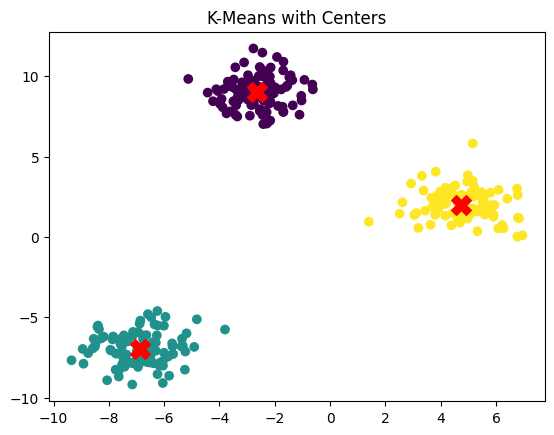

In [18]:
# Generate synthetic data with make_blobs and apply KMeans. 
# Plot cluster centers on top of data points

import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

X, _ = make_blobs(n_samples=300, centers=3, random_state=42)

kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=labels)
plt.scatter(kmeans.cluster_centers_[:, 0], 
            kmeans.cluster_centers_[:, 1], 
            c='red', marker='X', s=200)
plt.title("K-Means with Centers")
plt.show()

In [19]:
# Load the Iris dataset, cluster with DBSCAN, 
# and print number of noise samples

import numpy as np
from sklearn.datasets import load_iris
from sklearn.cluster import DBSCAN

X = load_iris().data

db = DBSCAN(eps=0.5, min_samples=5)
labels = db.fit_predict(X)

noise_count = np.sum(labels == -1)
print("Noise points:", noise_count)

Noise points: 17


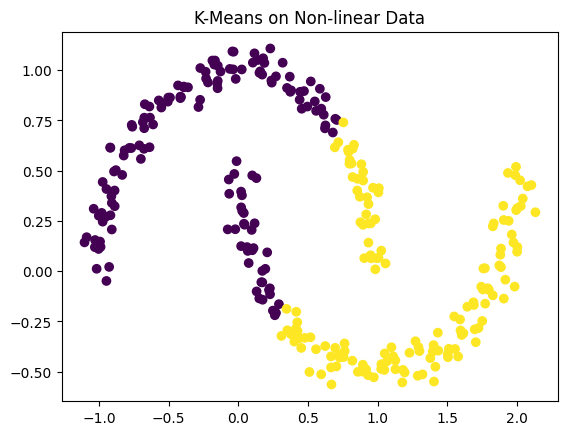

In [20]:
# Generate non-linearly separable data using make_moons, 
# apply K-Means, and visualize clustering

import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.cluster import KMeans

X, _ = make_moons(n_samples=300, noise=0.05, random_state=42)

kmeans = KMeans(n_clusters=2, random_state=42)
labels = kmeans.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=labels)
plt.title("K-Means on Non-linear Data")
plt.show()

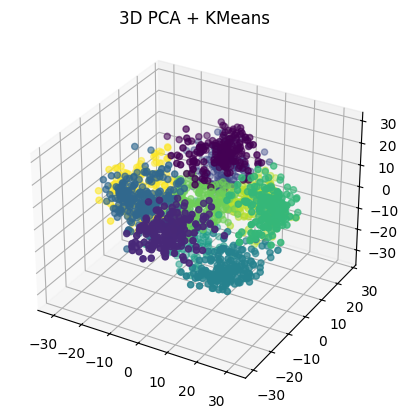

In [21]:
# Load the Digits dataset, apply PCA to 3 components, 
# then use KMeans and visualize with 3D scatter plot

import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

from mpl_toolkits.mplot3d import Axes3D

digits = load_digits()
X = digits.data

X_pca = PCA(n_components=3).fit_transform(X)

kmeans = KMeans(n_clusters=10, random_state=42)
labels = kmeans.fit_predict(X_pca)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=labels)
ax.set_title("3D PCA + KMeans")

plt.show()

In [22]:
# Generate synthetic blobs with 5 centers and apply KMeans.
# Then use silhouette_score to evaluate clustering

from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X, _ = make_blobs(n_samples=300, centers=5, random_state=42)

kmeans = KMeans(n_clusters=5, random_state=42)
labels = kmeans.fit_predict(X)

score = silhouette_score(X, labels)
print("Silhouette Score:", score)

Silhouette Score: 0.6529948721222021


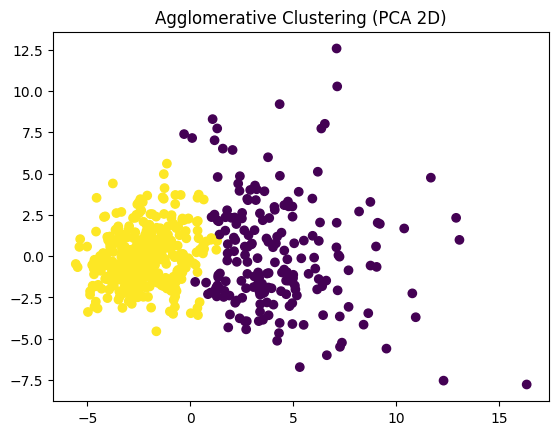

In [23]:
# Load the Breast Cancer dataset, reduce dimensionality using PCA,
# and apply Agglomerative Clustering. Visualize in 2D

import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler

X = StandardScaler().fit_transform(load_breast_cancer().data)

X_pca = PCA(n_components=2).fit_transform(X)

agg = AgglomerativeClustering(n_clusters=2)
labels = agg.fit_predict(X_pca)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels)
plt.title("Agglomerative Clustering (PCA 2D)")
plt.show()

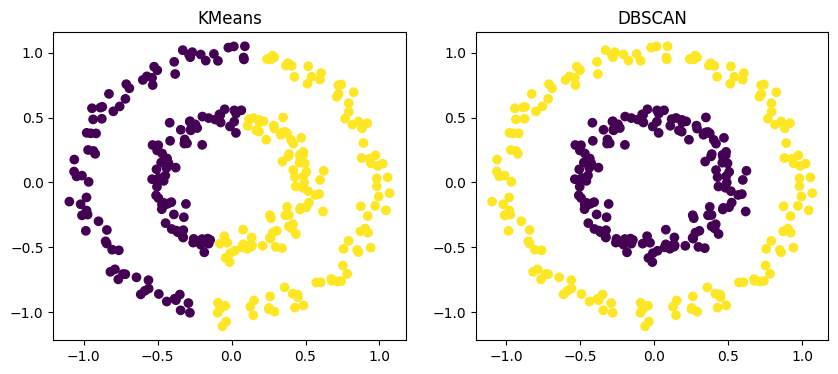

In [24]:
# Generate noisy circular data using make_circles and visualize clustering
# results from KMeans and DBSCAN side-by-side

import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.cluster import KMeans, DBSCAN

X, _ = make_circles(n_samples=300, noise=0.05, factor=0.5, random_state=42)

kmeans = KMeans(n_clusters=2, random_state=42)
k_labels = kmeans.fit_predict(X)

db = DBSCAN(eps=0.2, min_samples=5)
d_labels = db.fit_predict(X)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], c=k_labels)
plt.title("KMeans")

plt.subplot(1, 2, 2)
plt.scatter(X[:, 0], X[:, 1], c=d_labels)
plt.title("DBSCAN")

plt.show()

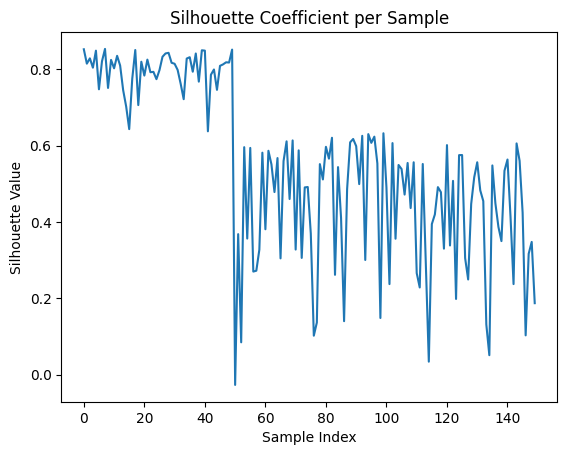

In [25]:
# Load the Iris dataset and plot the Silhouette Coefficient for each sample after KMeans

import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples

X = load_iris().data

kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X)

sil_values = silhouette_samples(X, labels)

plt.plot(sil_values)
plt.title("Silhouette Coefficient per Sample")
plt.xlabel("Sample Index")
plt.ylabel("Silhouette Value")
plt.show()

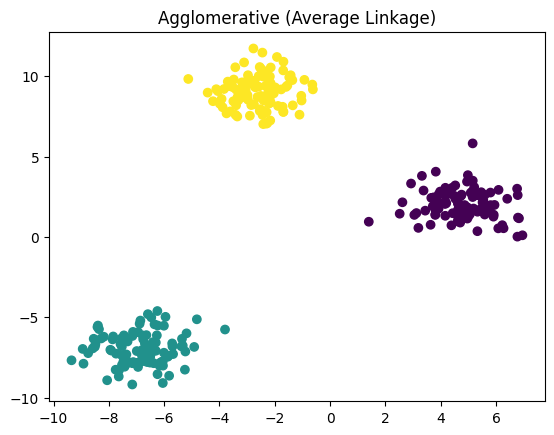

In [26]:
# Generate synthetic data using make_blobs and apply Agglomerative Clustering
# with 'average' linkage. Visualize clusters

import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering

X, _ = make_blobs(n_samples=300, centers=3, random_state=42)

agg = AgglomerativeClustering(n_clusters=3, linkage='average')
labels = agg.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=labels)
plt.title("Agglomerative (Average Linkage)")
plt.show()

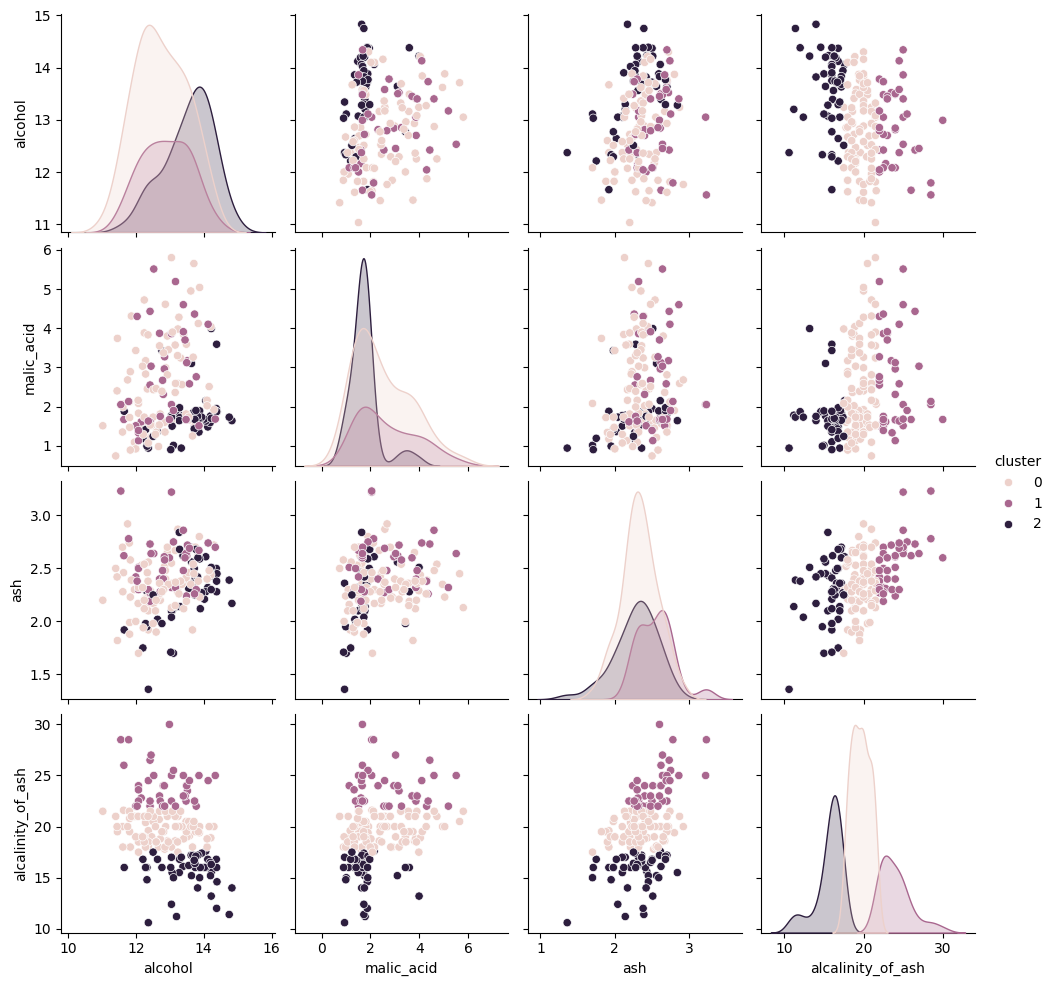

In [30]:
# Load the Wine dataset, apply KMeans, and visualize cluster assignments
# in a seaborn pairplot (first 4 features)

import seaborn as sns
import pandas as pd
from sklearn.datasets import load_wine
from sklearn.cluster import KMeans

wine = load_wine()
X = wine.data[:, :4]

kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X)

df = pd.DataFrame(X, columns=wine.feature_names[:4])
df['cluster'] = labels

sns.pairplot(df, hue='cluster')

In [28]:
# Generate noisy blobs using make_blobs and use DBSCAN to identify
# both clusters and noise points. Print the count

import numpy as np
from sklearn.datasets import make_blobs
from sklearn.cluster import DBSCAN

X, _ = make_blobs(n_samples=300, centers=3, cluster_std=2.0, random_state=42)

db = DBSCAN(eps=1.0, min_samples=5)
labels = db.fit_predict(X)

clusters = len(set(labels)) - (1 if -1 in labels else 0)
noise = np.sum(labels == -1)

print("Clusters:", clusters)
print("Noise points:", noise)

Clusters: 5
Noise points: 52


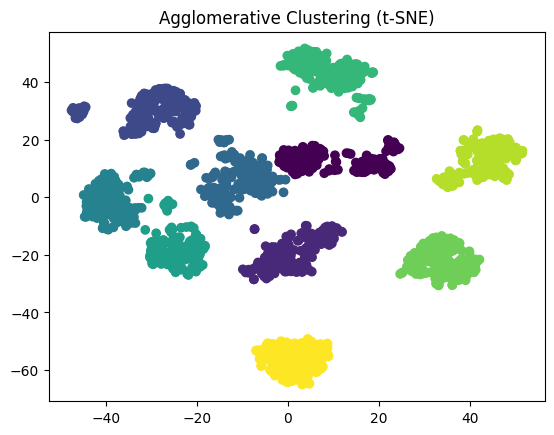

In [31]:
# Load the Digits dataset, reduce dimensions using t-SNE,
# then apply Agglomerative Clustering and plot the clusters

import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.manifold import TSNE
from sklearn.cluster import AgglomerativeClustering

digits = load_digits()
X = digits.data

X_tsne = TSNE(n_components=2, random_state=42).fit_transform(X)

agg = AgglomerativeClustering(n_clusters=10)
labels = agg.fit_predict(X_tsne)

plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels)
plt.title("Agglomerative Clustering (t-SNE)")
plt.show()